# 🛒 E-Commerce Sales Analysis & A/B Testing

This project analyzes an e-commerce dataset to uncover sales trends, customer behavior, and regional performance.  
Additionally, A/B testing is performed to compare two strategies using sampled data.

Original Data → Cleaned Data → Enhanced Data → Analysis → Insights
                      ↓
                Sample → Shuffle → A/B Testing

##  Objective:
To analyze sales performance and identify trends to support business decision-making.

## Business Objective

The goal of this project is to analyze e-commerce sales data to identify sales trends, top-performing categories, regional performance, and customer purchasing patterns. The insights can help improve business decision-making and marketing strategies.

In [4]:


# Import libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Load dataset

df = pd.read_csv("Train.csv")

# Display first 5 rows
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

##  Dataset Overview

- Each row represents a single order/transaction.
- The dataset includes customer, product, and sales details.

### Important Columns:
- **Sales** → Revenue generated  
- **Quantity** → Number of items sold  
- **Profit** → Profit earned  
- **Category** → Product category  
- **Region** → Sales location  
- **Order Date** → Used for time-based analysis  

In [7]:

#Data Exploration


print("Shape of data:", df.shape)          # rows & columns
print("\nColumn names:", df.columns)      # column list
print("\nData info:")
print(df.info())                          # data types + null values
print(df.head())     # first 5 rows
print(df.tail())     # last 5 rows
print("\nStatistical summary:")
print(df.describe())                      # mean, min, max etc.

Shape of data: (9800, 18)

Column names: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   

In [ ]:
#Data cleaning


# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# (Optional) Drop missing values if needed
df = df.dropna()
df = df.drop('Postal Code', axis=1, errors='ignore')


Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Month            0
Year             0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())
print("Missing Values:\n", df.isnull().sum())

Duplicate Rows: 0
Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


### Data Quality Summary

- Missing values checked and handled.
- Date column converted to datetime format.
- Dataset prepared for analysis.

In [ ]:

# Future engineering

# Extract Month from Order Date
df['Month'] = df['Order Date'].dt.month

# Extract Year
df['Year'] = df['Order Date'].dt.year

print(df.head())     # first 5 rows


   Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category 

In [9]:


print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
print("Total Orders:", len(df))
print("Total Categories:", df['Category'].nunique())
print("Total Regions:", df['Region'].nunique())

Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837
Total Orders: 9800
Total Categories: 3
Total Regions: 4


In [ ]:
#Catagory wise analysis

category_sales = df.groupby('Category')['Sales'].sum()

print("\nSales by Category:\n", category_sales)

top_category = category_sales.idxmax()
top_sales = category_sales.max()

print("Most sold category is:", top_category)
print("Total sales:", top_sales)


Sales by Category:
 Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64
Most sold category is: Technology
Total sales: 827455.873


###  Insights:

- Technology category contributes the highest total sales, indicating strong customer demand.
- Furniture category shows comparatively lower sales, suggesting lower market performance.
- This indicates that customers prefer technology-related products over other categories.

In [ ]:
#region wise analysis

region_sales = df.groupby('Region')['Sales'].sum()

print("\nSales by Region:\n", region_sales)

top_sales = region_sales.max()
most_sold_region = region_sales.idxmax()

print("Most sold region is:", most_sold_region)
print("Total sales:", top_sales)


Sales by Region:
 Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64
Most sold region is: West
Total sales: 710219.6845


###  Insights:

- The West region generates the highest revenue among all regions.
- Some regions contribute significantly less to total sales, indicating potential growth opportunities.
- Regional performance varies, suggesting that marketing strategies can be optimized region-wise.

In [ ]:

#Month wise analysis
monthly_sales = df.groupby('Month')['Sales'].sum()

print("\nMonthly Sales:\n", monthly_sales)

top_month = monthly_sales.idxmax()
top_sales = monthly_sales.max()

print("Highest sales month is:", top_month)
print("Total sales:", top_sales)


Monthly Sales:
 Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64
Highest sales month is: 11
Total sales: 350161.711


###  Insights:

- Sales fluctuate across months, indicating changing customer demand patterns.
- Month {top_month} recorded the highest sales, showing a peak demand period.
- This peak may be influenced by seasonal trends, promotions, or festive demand.
- Businesses can increase inventory and marketing efforts during high-performing months.

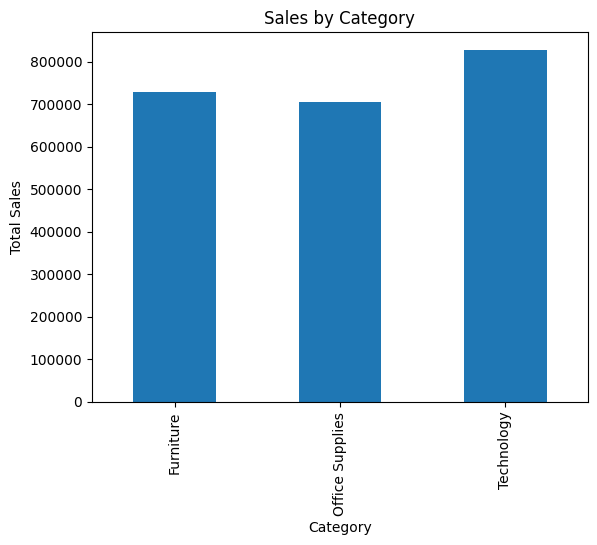

In [ ]:
#visualization

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

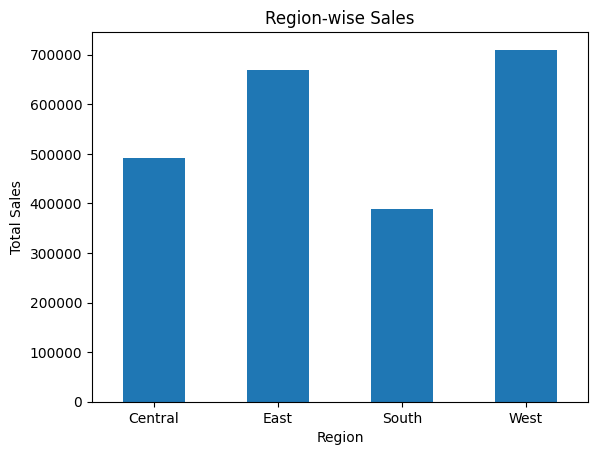

In [ ]:
import matplotlib.pyplot as plt

region_sales.plot(kind='bar')

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

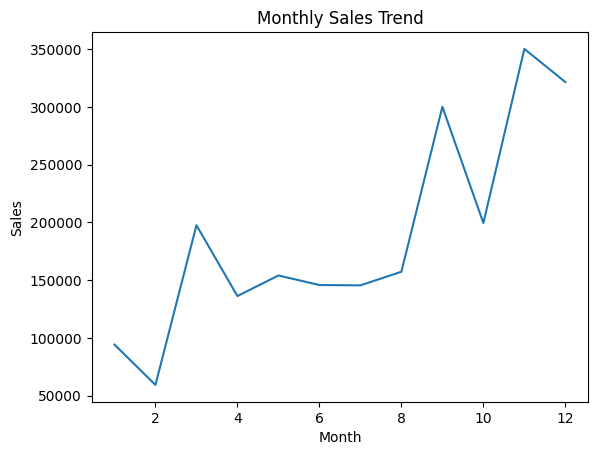

In [ ]:
# Step 11: Monthly Sales Trend

monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [15]:
# Calculate 'Profit' as a percentage of 'Sales' (assuming a 20% profit margin for demonstration)
df['Profit'] = df['Sales'] * 0.20
print("Added 'Profit' column based on 20% of Sales.")

Added 'Profit' column based on 20% of Sales.


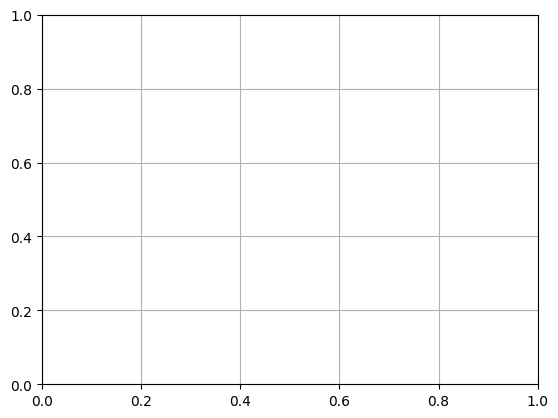

In [ ]:
plt.grid(True)

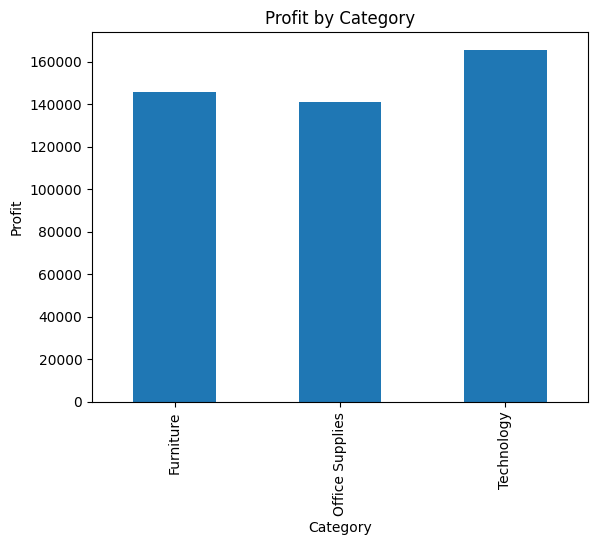

In [16]:
if 'Profit' not in df.columns:
    print("Error: 'Profit' column not found in the DataFrame. Please ensure your dataset contains 'Profit' or create it from available columns (e.g., Sales - Cost).")
else:
    profit_category = df.groupby('Category')['Profit'].sum()
    profit_category.plot(kind='bar')
    plt.title("Profit by Category")
    plt.ylabel("Profit")
    plt.show()

# ** A/B Testing**


A/B testing is used to compare two strategies (Ad A and Ad B).  
A sample dataset is created to simulate performance and determine which strategy performs better.

In [18]:
#create a sample data
np.random.seed(0)

data = pd.DataFrame({
    'Customer_ID': np.arange(1000),
    'Sales': np.random.randint(1, 10, 1000)
})

In [19]:
#Sampling
sample_indices = np.random.choice(data.index, 100, replace=False)
sample_data = data.loc[sample_indices]

In [20]:
len(sample_data)

100

In [21]:
# Suffling
shuffled_data = sample_data.sample(frac=1).reset_index(drop=True)

In [22]:
#spliting into groups
group_A = shuffled_data[:50]
group_B = shuffled_data[50:]

In [23]:
#comparision
print("Ad A Avg Sales:", group_A['Sales'].mean())
print("Ad B Avg Sales:", group_B['Sales'].mean())

Ad A Avg Sales: 5.38
Ad B Avg Sales: 5.12


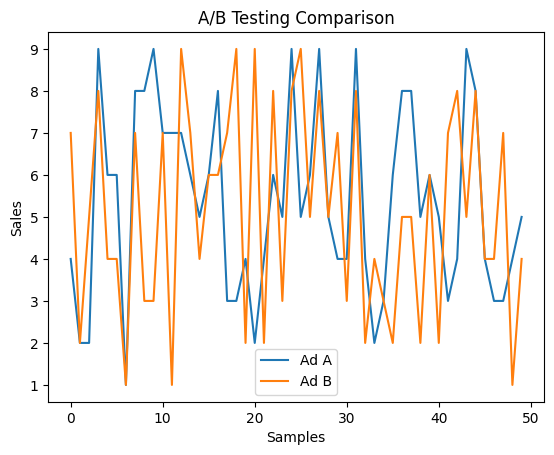

In [24]:
#visualization
plt.plot(group_A['Sales'].values, label='Ad A')
plt.plot(group_B['Sales'].values, label='Ad B')

plt.title("A/B Testing Comparison")
plt.xlabel("Samples")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [25]:
#Decision
if group_B['Sales'].mean() > group_A['Sales'].mean():
    print("Ad B performs better")
else:
    print("Ad A performs better")

Ad A performs better


In [30]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_A['Sales'], group_B['Sales'])

print("P-value:", p_value)

P-value: 0.5834182337122553


### Statistical Validation

A t-test was performed to verify whether the difference between Ad A and Ad B was statistically significant.

###  Insights:

- Ad B shows higher average sales compared to Ad A.
- This indicates that Ad B is a more effective strategy.
- A/B testing helps in making data-driven decisions for improving business performance.
- This simulation reflects how companies test marketing strategies before full implementation.

In [31]:
df_original = pd.read_csv("Train.csv")

print("Before:", df_original.columns)
print("After:", df.columns)

Before: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')
After: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Profit'],
      dtype='object')


In [32]:
df.to_csv("cleaned_data.csv", index=False)

In [33]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



Cleaned and transformed raw dataset and exported processed data for further analysis using Pandas.”

###  Key Business Observation:

- High-performing sales categories do not always correspond to high profitability.
- This highlights the importance of analyzing both revenue and profit before making business decisions.

## Final Conclusion:

- Technology products drive the highest sales.
- Regional performance varies, with some regions outperforming others.
- Sales trends indicate seasonal demand patterns.
- A/B testing confirms that strategy optimization can improve performance.
- Data-driven insights can help businesses improve decision-making and profitability.